<a href="https://colab.research.google.com/github/ryrynbob/ust-deep-learning-2026/blob/main/Week6_Ryan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment Week 6

## Presentation

Brief introduction to your data set

Description of the autoencoder implementation including architecture

Plot of the latent embedding and discussion of how it represents the data set

## Load and inspect for Visualization

In [19]:
import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

## Load Dataset and check

In [3]:
path = "/atp_matches_2023.csv"  # upload to Colab or mount Drive
df = pd.read_csv(path)

In [4]:
df.shape()

(2242, 49)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2242 entries, 0 to 2241
Data columns (total 49 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tourney_id          2242 non-null   object 
 1   tourney_name        2242 non-null   object 
 2   surface             2242 non-null   object 
 3   draw_size           2242 non-null   int64  
 4   tourney_level       2242 non-null   object 
 5   tourney_date        2242 non-null   int64  
 6   match_num           2242 non-null   int64  
 7   winner_id           2242 non-null   int64  
 8   winner_seed         947 non-null    float64
 9   winner_entry        367 non-null    object 
 10  winner_name         2242 non-null   object 
 11  winner_hand         2242 non-null   object 
 12  winner_ht           2123 non-null   float64
 13  winner_ioc          2242 non-null   object 
 14  winner_age          2242 non-null   float64
 15  loser_id            2242 non-null   int64  
 16  loser_

In [6]:
df.describe()

,draw_size,tourney_date,match_num,winner_id,winner_seed,winner_ht,winner_age,loser_id,loser_seed,loser_ht,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
count,2242.000000,2.242000e+03,2242.000000,2242.000000,947.000000,2123.000000,2242.000000,2242.000000,587.000000,2019.000000,...,2129.000000,2129.000000,2129.000000,2129.000000,2129.000000,2129.000000,2231.000000,2231.000000,2221.000000,2221.000000
mean,67.454059,2.023044e+07,243.868867,143004.590098,7.814150,187.310410,26.616325,141581.216325,9.846678,186.535414,...,50.426491,33.821982,14.621419,12.458431,4.757163,8.423203,75.090542,1636.746750,111.577217,1049.325979
std,45.272834,2.280950e+02,71.174683,41912.968871,7.151582,6.285256,4.281716,41539.799299,8.117545,6.470571,...,19.271394,14.456402,6.809190,4.210317,3.266187,4.133788,118.308201,1666.536965,167.645209,1073.510850
min,4.000000,2.023010e+07,1.000000,100644.000000,1.000000,170.000000,17.900000,100644.000000,1.000000,170.000000,...,3.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,32.000000,2.023022e+07,220.000000,106329.000000,3.000000,183.000000,24.000000,106214.000000,4.000000,183.000000,...,36.000000,24.000000,10.000000,9.000000,2.000000,5.000000,18.000000,655.000000,38.000000,531.000000
50%,32.000000,2.023042e+07,276.000000,126203.000000,6.000000,185.000000,26.100000,126106.000000,7.000000,185.000000,...,47.000000,31.000000,14.000000,12.000000,4.000000,8.000000,50.000000,880.000000,69.000000,771.000000
75%,128.000000,2.023063e+07,289.000000,200282.000000,10.000000,191.000000,28.800000,200221.000000,14.000000,191.000000,...,61.000000,42.000000,18.000000,15.000000,7.000000,11.000000,87.000000,2050.000000,111.000000,1046.000000
max,128.000000,2.023082e+07,300.000000,210506.000000,32.000000,206.000000,41.700000,212041.000000,32.000000,206.000000,...,143.000000,101.000000,47.000000,31.000000,19.000000,28.000000,1594.000000,9395.000000,1859.000000,9395.000000


In [7]:
df.head()

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2023-9900,United Cup,Hard,18,A,20230102,300,126203,3.0,NaN,...,62.0,47.0,15.0,12.0,9.0,9.0,9.0,3355.0,16.0,2375.0
1,2023-9900,United Cup,Hard,18,A,20230102,299,126207,NaN,NaN,...,12.0,8.0,3.0,4.0,1.0,3.0,19.0,2000.0,23.0,1865.0
2,2023-9900,United Cup,Hard,18,A,20230102,296,126203,3.0,NaN,...,62.0,51.0,7.0,12.0,2.0,2.0,9.0,3355.0,10.0,2905.0
3,2023-9900,United Cup,Hard,18,A,20230102,295,126207,NaN,NaN,...,41.0,26.0,12.0,9.0,6.0,9.0,19.0,2000.0,245.0,220.0
4,2023-9900,United Cup,Hard,18,A,20230102,292,126774,1.0,NaN,...,58.0,48.0,18.0,16.0,1.0,2.0,4.0,5550.0,16.0,2375.0


In [8]:
df.tail()

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
2237,2023-M-DC-2023-WG2-PO-RSA-LUX-01,Davis Cup WG2 PO: RSA vs LUX,Hard,4,D,20230204,5,202335,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1717.0,1.0
2238,2023-M-DC-2023-WG2-PO-TUN-CYP-01,Davis Cup WG2 PO: TUN vs CYP,Hard,4,D,20230203,1,117365,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,990.0,11.0,279.0,190.0
2239,2023-M-DC-2023-WG2-PO-TUN-CYP-01,Davis Cup WG2 PO: TUN vs CYP,Hard,4,D,20230203,2,121411,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,364.0,131.0,894.0,15.0
2240,2023-M-DC-2023-WG2-PO-TUN-CYP-01,Davis Cup WG2 PO: TUN vs CYP,Hard,4,D,20230203,4,144949,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,894.0,15.0,285.0,184.0
2241,2023-M-DC-2023-WG2-PO-TUN-CYP-01,Davis Cup WG2 PO: TUN vs CYP,Hard,4,D,20230203,5,121411,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,364.0,131.0,990.0,11.0


In [9]:
df.isnull().sum()

,0
tourney_id,0
tourney_name,0
surface,0
draw_size,0
tourney_level,0
tourney_date,0
match_num,0
winner_id,0
winner_seed,1295
winner_entry,1875


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
# label for visualization
label_col = "surface"
print(df[label_col].value_counts(dropna=False))

surface
Hard     1040
Clay      878
Grass     324
Name: count, dtype: int64


## Choose Features (keep numeric match stats,  drop identifier and names)

In [15]:
# Keep metadata for later reporting (not for training)
meta_cols = ["tourney_name", "tourney_level", "round", "winner_name", "loser_name", "score"]
meta = df[meta_cols + [label_col]].copy()

# Columns to drop from modeling (IDs/names/text labels)
drop_cols = [
    "tourney_id", "tourney_name", "tourney_date", "match_num",
    "winner_id", "winner_name", "loser_id", "loser_name", "score",
    "winner_ioc", "loser_ioc"
]

# We'll treat these as categorical predictors (optional but useful)
cat_cols = ["tourney_level", "round", "winner_hand", "loser_hand"]

# Label column used only for coloring/EDA
# (do NOT include it in X)
drop_cols += [label_col]

X_raw = df.drop(columns=[c for c in drop_cols if c in df.columns])




In [16]:
X_work = X_raw.copy()

num_cols, cat_cols = [], []

for c in X_work.columns:
    if pd.api.types.is_numeric_dtype(X_work[c]):
        num_cols.append(c)
    else:
        # try coercing object columns to numeric
        coerced = pd.to_numeric(X_work[c], errors="coerce")
        # if almost everything becomes numeric, treat it as numeric
        if coerced.notna().mean() >= 0.95:
            X_work[c] = coerced
            num_cols.append(c)
        else:
            cat_cols.append(c)

print("Numeric cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))
print("Categorical examples:", cat_cols[:15])

Numeric cols: 31
Categorical cols: 6
Categorical examples: ['tourney_level', 'winner_entry', 'winner_hand', 'loser_entry', 'loser_hand', 'round']


In [ ]:
# Make sure categorical columns exist in X_raw
cat_cols = [c for c in cat_cols if c in X_raw.columns]

# Everything else numeric
num_cols = [c for c in X_raw.columns if c not in cat_cols]

print("Numeric cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))

## Preprocess (impute missing + one-hot + scale)

In [18]:


y = df[label_col].copy()

X_train_raw, X_test_raw, y_train, y_test, meta_train, meta_test = train_test_split(
    X_raw, y, meta, test_size=0.2, random_state=42, stratify=y
)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

X_train = preprocess.fit_transform(X_train_raw)
X_test  = preprocess.transform(X_test_raw)

# Convert sparse -> dense if needed
X_train = X_train.toarray() if hasattr(X_train, "toarray") else X_train
X_test  = X_test.toarray()  if hasattr(X_test, "toarray")  else X_test

print("Processed train shape:", X_train.shape)
print("Processed test shape:", X_test.shape)


Processed train shape: (1793, 61)
Processed test shape: (449, 61)


## Build the Autoencoder (Dense, tabular) + compile with MSE

In [20]:
input_dim = X_train.shape[1]
latent_dim = 2  # set 2 for an easy 2D embedding plot (great for slides)

encoder = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(latent_dim, name="z")  # bottleneck
], name="encoder")

decoder = keras.Sequential([
    layers.Input(shape=(latent_dim,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(input_dim, activation="linear")  # reconstruct scaled features
], name="decoder")


In [21]:
inp = keras.Input(shape=(input_dim,))
z = encoder(inp)
out = decoder(z)
autoencoder = keras.Model(inp, out, name="autoencoder")

autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 61)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Sequential)            │ (None, 2)              │        18,338 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 61)             │        18,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,735 (143.50 KB)

 Trainable params: 36,735 (143.50 KB)

 Non-trainable params: 0 (0.00 B)

## Train + Learning Curves

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.5759 - val_loss: 0.4124
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4005 - val_loss: 0.3535
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3539 - val_loss: 0.3344
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3423 - val_loss: 0.3171
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3200 - val_loss: 0.3033
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3131 - val_loss: 0.2963
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3085 - val_loss: 0.2909
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3018 - val_loss: 0.2876
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3044 - val_loss: 0.2836
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2887 - val_loss: 0.2809
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2952 - val_loss: 0.2785
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.

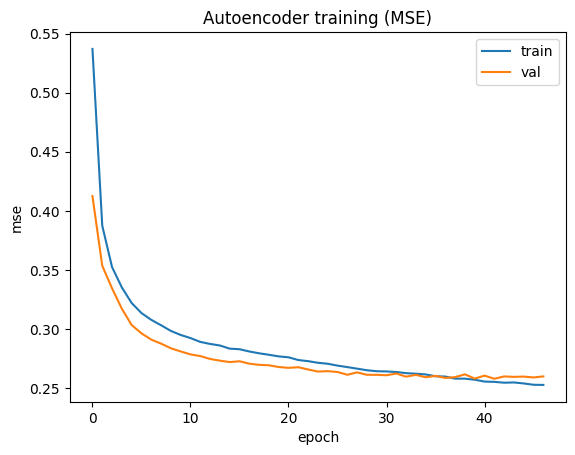

In [22]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]

hist = autoencoder.fit(
    X_train, X_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

plt.figure()
plt.plot(hist.history["loss"], label="train")
plt.plot(hist.history["val_loss"], label="val")
plt.title("Autoencoder training (MSE)")
plt.xlabel("epoch"); plt.ylabel("mse"); plt.legend()
plt.show()

## Reconstruction quality + per-sample reconstruction error (anomaly detection)

high MSE = unusual match (anomaly detection is explicitly listed as a core AE application)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


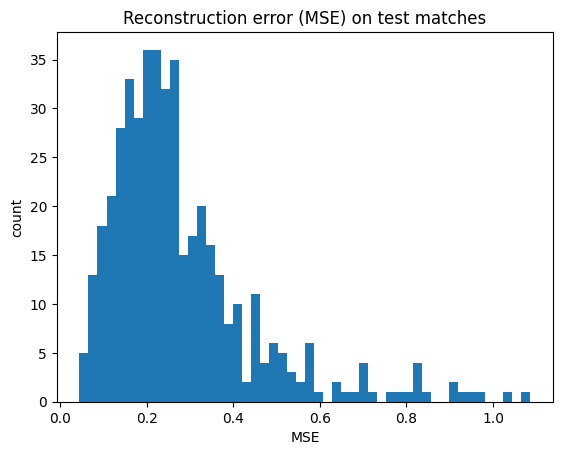

,tourney_name,tourney_level,round,winner_name,loser_name,score,surface,recon_mse
659,Indian Wells Masters,M,R64,Tallon Griekspoor,Guido Pella,7-6(3) 7-6(4),Hard,1.086071
1102,Madrid Masters,M,R64,Jan Lennard Struff,Ben Shelton,4-6 7-6(4) 7-5,Clay,1.027940
775,Miami Masters,M,R64,Alex Molcan,Yoshihito Nishioka,7-6(5) 1-6 6-2,Hard,0.961541
905,Monte Carlo Masters,M,R16,Lorenzo Musetti,Novak Djokovic,4-6 7-5 6-4,Clay,0.943212
274,Australian Open,G,R16,Stefanos Tsitsipas,Jannik Sinner,6-4 6-4 3-6 4-6 6-3,Hard,0.936458
892,Marrakech,A,R32,Roberto Carballes Baena,Maxime Cressy,6-7(4) 6-3 6-1,Clay,0.916199
186,Australian Open,G,R128,Christopher Eubanks,Soon Woo Kwon,6-3 6-7(1) 6-3 4-6 6-4,Hard,0.902560
1715,Wimbledon,G,QF,Carlos Alcaraz,Holger Rune,7-6(3) 6-4 6-4,Grass,0.841711
1164,Rome Masters,M,R32,Novak Djokovic,Grigor Dimitrov,6-3 4-6 6-1,Clay,0.833992
286,Australian Open,G,F,Novak Djokovic,Stefanos Tsitsipas,6-3 7-6(4) 7-6(5),Hard,0.826322


In [23]:
X_test_hat = autoencoder.predict(X_test)

# per-sample reconstruction MSE
recon_mse = np.mean((X_test - X_test_hat)**2, axis=1)

plt.figure()
plt.hist(recon_mse, bins=50)
plt.title("Reconstruction error (MSE) on test matches")
plt.xlabel("MSE"); plt.ylabel("count")
plt.show()

# Show top anomalies
top_idx = np.argsort(recon_mse)[-10:][::-1]
anoms = meta_test.iloc[top_idx].copy()
anoms["recon_mse"] = recon_mse[top_idx]
display(anoms)


## Latent embedding plot (Required) + discussion

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


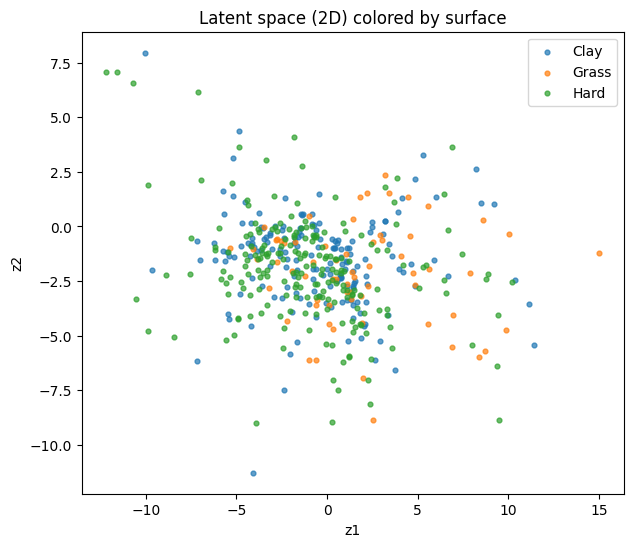

In [24]:
Z_test = encoder.predict(X_test)

plt.figure(figsize=(7,6))
for s in sorted(y_test.unique()):
    mask = (y_test.values == s)
    plt.scatter(Z_test[mask, 0], Z_test[mask, 1], s=12, alpha=0.7, label=s)

plt.title("Latent space (2D) colored by surface")
plt.xlabel("z1"); plt.ylabel("z2")
plt.legend()
plt.show()
